# 3.2 Illustrative ligand-screening examples from external validation


In [28]:
from __future__ import annotations

from collections import OrderedDict
from itertools import combinations
from pathlib import Path
import hashlib
import math
import re
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import SVG, display

from rdkit import Chem, RDLogger
from rdkit.Chem import Draw

RDLogger.DisableLog("rdApp.*")


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    required = [
        Path(
            "results/3_1_recent_aho_external_validation/"
            "tables/external_predictions.csv"
        ),
        Path(
            "results/3_1_recent_aho_external_validation/"
            "tables/external_metrics_all_selected_models.csv"
        ),
    ]
    for candidate in [start, *start.parents]:
        if all((candidate / relative_path).exists() for relative_path in required):
            return candidate
    return start


PROJECT_ROOT = find_project_root()

PREDICTION_PATH = (
    PROJECT_ROOT
    / "results"
    / "3_1_recent_aho_external_validation"
    / "tables"
    / "external_predictions.csv"
)
METRICS_PATH = (
    PROJECT_ROOT
    / "results"
    / "3_1_recent_aho_external_validation"
    / "tables"
    / "external_metrics_all_selected_models.csv"
)

RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "3_2_reaction_series_case_analysis"
)
TABLE_DIR = RESULT_DIR / "tables"
FIGURE_DIR = RESULT_DIR / "figures"
STRUCTURE_DIR = RESULT_DIR / "structures"
for directory in [RESULT_DIR, TABLE_DIR, FIGURE_DIR, STRUCTURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# Case-discovery parameters
# ------------------------------------------------------------------
MIN_UNIQUE_ITEMS = 2
MIN_EXPERIMENTAL_SPREAD = 0.50
PAIR_TRUE_TOLERANCE = 0.05
PREDICTED_TIE_TOLERANCE = 0.05
COMPRESSION_RATIO_THRESHOLD = 0.40

# ------------------------------------------------------------------
# Main-text illustrative display plan
# ------------------------------------------------------------------
# Each slot is filled automatically from the complete pair/triplet ranking.
# The plan controls only the type and number of displayed structures; it
# never specifies which series or item IDs are selected.
DISPLAY_CASE_PLAN = [
    {
        "case_slot": 1,
        "series_type": "ligand_variation",
        "subset_size": 3,
        "display_label": "Substrate 1 ligand screen",
    },
    {
        "case_slot": 2,
        "series_type": "ligand_variation",
        "subset_size": 3,
        "display_label": "Substrate 2 ligand screen",
    },
]

REQUIRE_DISTINCT_SERIES = True
REQUIRE_DISTINCT_CONTEXT_WITHIN_TYPE = True
ALLOWED_DISPLAY_TIERS = {"A", "B"}

# Subset-score weights. Trend reproduction is intentionally emphasized over
# absolute pointwise calibration because the figure illustrates relative
# ligand response.
DISPLAY_SCORE_WEIGHTS = {
    "aligned_order": 2.0,
    "order_advantage": 3.0,
    "delta_error_advantage": 2.0,
    "range_advantage": 1.0,
    "competitor_failure_count": 0.8,
    "experimental_spread": 0.35,
}

SCENARIO_ORDER = [
    "Target-only",
    "Mechanism-mismatched transfer",
    "Mechanism-aligned transfer",
]
SCENARIO_SHORT = {
    "Target-only": "target_only",
    "Mechanism-aligned transfer": "mechanism_aligned",
    "Mechanism-mismatched transfer": "mechanism_mismatched",
}
SCENARIO_LABELS = {
    "target_only": "Target-only",
    "mechanism_aligned": "Mechanism-aligned",
    "mechanism_mismatched": "Mechanism-mismatched",
}
SCENARIO_COLORS = {
    "experimental": "#111111",
    "target_only": "#009E73",
    "mechanism_aligned": "#0072B2",
    "mechanism_mismatched": "#D55E00",
}
SCENARIO_MARKERS = {
    "experimental": "o",
    "target_only": "s",
    "mechanism_aligned": "^",
    "mechanism_mismatched": "D",
}

# Optional study identifiers are included in a grouping key when present.
STUDY_ID_CANDIDATES = [
    "DOI",
    "Reference DOI",
    "Reference",
    "Source",
    "Literature",
]

BASE_CONTEXT_COLUMNS = [
    "Reaction Year",
    "Metal",
    "Solvent SMILES",
    "Additive SMILES",
    "Pressure/atm",
    "Temperature/C",
    "S/C",
]
NUMERIC_CONTEXT_COLUMNS = {
    "Reaction Year",
    "Pressure/atm",
    "Temperature/C",
    "S/C",
}

SERIES_DEFINITIONS = OrderedDict(
    [
        (
            "ligand_variation",
            {
                "label": "Ligand variation",
                "varying_column": "Ligand SMILES",
                "item_prefix": "L",
                "fixed_columns": [
                    "Reactant SMILES",
                    "Product SMILES",
                    *BASE_CONTEXT_COLUMNS,
                ],
                "fixed_structure_column": "Reactant SMILES",
                "fixed_structure_label": "Fixed substrate",
                "varying_structure_label": "Ligand",
            },
        ),
    ]
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)

print("Prediction table:", PREDICTION_PATH.relative_to(PROJECT_ROOT))
print("Metrics table:", METRICS_PATH.relative_to(PROJECT_ROOT))
print("Output directory:", RESULT_DIR.relative_to(PROJECT_ROOT))
print(
    "Display case plan:",
    [
        {
            "case_slot": entry["case_slot"],
            "series_type": entry["series_type"],
            "subset_size": entry["subset_size"],
        }
        for entry in DISPLAY_CASE_PLAN
    ],
)


Prediction table: results/3_1_recent_aho_external_validation/tables/external_predictions.csv
Metrics table: results/3_1_recent_aho_external_validation/tables/external_metrics_all_selected_models.csv
Output directory: results/3_2_reaction_series_case_analysis
Display case plan: [{'case_slot': 1, 'series_type': 'ligand_variation', 'subset_size': 3}, {'case_slot': 2, 'series_type': 'ligand_variation', 'subset_size': 3}]


## 1. Load notebook 3.1 outputs and identify the three ensemble predictions


In [29]:
def safe_name(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(text).lower()).strip("_")


if not PREDICTION_PATH.exists():
    raise FileNotFoundError(
        f"Run notebook 3.1 before notebook 3.2. Missing: {PREDICTION_PATH}"
    )
if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"Run notebook 3.1 before notebook 3.2. Missing: {METRICS_PATH}"
    )

predictions = pd.read_csv(PREDICTION_PATH).reset_index(drop=True)
metrics = pd.read_csv(METRICS_PATH)

required_metric_columns = {
    "result_name",
    "scenario",
    "result_type",
}
missing_metric_columns = required_metric_columns - set(metrics.columns)
if missing_metric_columns:
    raise KeyError(
        f"Notebook 3.1 metrics are missing columns: "
        f"{sorted(missing_metric_columns)}"
    )

ensemble_rows = metrics.loc[
    metrics["result_type"].astype(str).str.casefold().eq("ensemble")
].copy()

scenario_prediction_columns = OrderedDict()
scenario_result_names = OrderedDict()

for scenario in SCENARIO_ORDER:
    matched = ensemble_rows.loc[
        ensemble_rows["scenario"].astype(str).eq(scenario)
    ]
    if len(matched) != 1:
        raise ValueError(
            f"Expected exactly one ensemble metric row for {scenario!r}; "
            f"found {len(matched)}."
        )

    result_name = str(matched.iloc[0]["result_name"])
    prediction_column = f"pred_{safe_name(result_name)}"
    if prediction_column not in predictions.columns:
        raise KeyError(
            f"Prediction column derived from {result_name!r} was not found: "
            f"{prediction_column}"
        )

    scenario_key = SCENARIO_SHORT[scenario]
    scenario_prediction_columns[scenario_key] = prediction_column
    scenario_result_names[scenario_key] = result_name

if "y_true" not in predictions.columns:
    raise KeyError("The notebook 3.1 prediction table is missing y_true.")
for required_structure_column in ["Reactant SMILES", "Ligand SMILES"]:
    if required_structure_column not in predictions.columns:
        raise KeyError(
            f"The prediction table is missing {required_structure_column}."
        )

prediction_column_audit = pd.DataFrame(
    [
        {
            "scenario_key": key,
            "scenario": SCENARIO_LABELS[key],
            "result_name": scenario_result_names[key],
            "prediction_column": column,
        }
        for key, column in scenario_prediction_columns.items()
    ]
)
prediction_column_audit.to_csv(
    TABLE_DIR / "ensemble_prediction_column_audit.csv",
    index=False,
)
display(prediction_column_audit)

print("Loaded external prediction rows:", len(predictions))


,scenario_key,scenario,result_name,prediction_column
0,target_only,Target-only,Target-only | 3 MACCS + 3 SPOC ensemble mean,pred_target_only_3_maccs_3_spoc_ensemble_mean
1,mechanism_mismatched,Mechanism-mismatched,Mechanism-mismatched transfer | 3 MACCS + 3 SP...,pred_mechanism_mismatched_transfer_3_maccs_3_s...
2,mechanism_aligned,Mechanism-aligned,Mechanism-aligned transfer | 3 MACCS + 3 SPOC ...,pred_mechanism_aligned_transfer_3_maccs_3_spoc...


Loaded external prediction rows: 103


## 2. Construct ligand-variation series


In [30]:
def normalize_text(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.casefold() in {"", "nan", "none", "null", "<na>"}:
        return ""
    return text


def canonicalize_smiles(value) -> str:
    text = normalize_text(value)
    if not text:
        return ""
    molecule = Chem.MolFromSmiles(text)
    if molecule is None:
        return text
    for atom in molecule.GetAtoms():
        atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(
        molecule,
        canonical=True,
        isomericSmiles=True,
    )


def normalize_numeric(value) -> str:
    numeric = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
    if pd.isna(numeric):
        return ""
    return f"{float(numeric):.6f}"


def normalized_group_value(table: pd.DataFrame, column: str) -> pd.Series:
    if column not in table.columns:
        return pd.Series("", index=table.index, dtype=object)
    if column.endswith("SMILES"):
        return table[column].map(canonicalize_smiles)
    if column in NUMERIC_CONTEXT_COLUMNS:
        return table[column].map(normalize_numeric)
    return table[column].map(normalize_text)


work = predictions.copy()
work["external_row_index"] = np.arange(len(work), dtype=int)
work["y_true"] = pd.to_numeric(work["y_true"], errors="coerce")
for column in scenario_prediction_columns.values():
    work[column] = pd.to_numeric(work[column], errors="coerce")

available_study_columns = [
    column
    for column in STUDY_ID_CANDIDATES
    if column in work.columns
]
print("Study-identity columns used:", available_study_columns)

all_series_parts = []
series_identity_rows = []

for series_type, definition in SERIES_DEFINITIONS.items():
    varying_column = definition["varying_column"]
    if varying_column not in work.columns:
        print(f"Skipping {series_type}: missing {varying_column}")
        continue

    context_columns = [
        *definition["fixed_columns"],
        *available_study_columns,
    ]
    # Remove duplicates while preserving order.
    context_columns = list(dict.fromkeys(context_columns))

    series_work = work.copy()
    series_work["_canonical_varying_item"] = (
        series_work[varying_column].map(canonicalize_smiles)
    )

    context_key_columns = []
    for column in context_columns:
        key_column = f"_group_{series_type}_{safe_name(column)}"
        series_work[key_column] = normalized_group_value(series_work, column)
        context_key_columns.append(key_column)

    series_work["_series_key"] = (
        series_work[context_key_columns]
        .astype(str)
        .agg("||".join, axis=1)
    )

    valid = (
        series_work["_canonical_varying_item"].ne("")
        & series_work["y_true"].notna()
    )
    for prediction_column in scenario_prediction_columns.values():
        valid &= series_work[prediction_column].notna()

    series_work = series_work.loc[valid].copy()

    for series_key, group in series_work.groupby("_series_key", sort=True):
        n_unique_items = group["_canonical_varying_item"].nunique()
        if n_unique_items < MIN_UNIQUE_ITEMS:
            continue

        aggregation_spec = {
            "varying_smiles": (varying_column, "first"),
            "n_replicates": ("external_row_index", "size"),
            "external_row_indices": (
                "external_row_index",
                lambda values: ";".join(map(str, sorted(values.astype(int)))),
            ),
            "y_true": ("y_true", "mean"),
            "y_true_sd": ("y_true", "std"),
        }
        if "Product SMILES" in group.columns:
            aggregation_spec["Product SMILES"] = ("Product SMILES", "first")
        for scenario_key, prediction_column in scenario_prediction_columns.items():
            aggregation_spec[f"pred_{scenario_key}"] = (
                prediction_column,
                "mean",
            )

        item_table = (
            group.groupby("_canonical_varying_item", as_index=False)
            .agg(**aggregation_spec)
        )
        item_table["y_true_sd"] = item_table["y_true_sd"].fillna(0.0)
        item_table = item_table.sort_values(
            ["y_true", "_canonical_varying_item"],
            ascending=[True, True],
            kind="mergesort",
        ).reset_index(drop=True)

        experimental_spread = float(
            item_table["y_true"].max()
            - item_table["y_true"].min()
        )
        if experimental_spread < MIN_EXPERIMENTAL_SPREAD:
            continue

        series_hash = hashlib.sha256(
            f"{series_type}||{series_key}".encode("utf-8")
        ).hexdigest()[:12]
        series_id = f"{series_type}_{series_hash}"

        item_table["series_id"] = series_id
        item_table["series_type"] = series_type
        item_table["series_type_label"] = definition["label"]
        item_table["item_order"] = np.arange(
            1,
            len(item_table) + 1,
            dtype=int,
        )
        item_table["item_id"] = [
            f"{definition['item_prefix']}{index}"
            for index in item_table["item_order"]
        ]
        item_table["canonical_item"] = item_table[
            "_canonical_varying_item"
        ]
        item_table = item_table.drop(columns="_canonical_varying_item")

        first = group.iloc[0]
        fixed_structure_column = definition["fixed_structure_column"]
        fixed_structure_smiles = (
            first[fixed_structure_column]
            if fixed_structure_column in group.columns
            else ""
        )
        fixed_structure_canonical = canonicalize_smiles(
            fixed_structure_smiles
        )

        # Used only to avoid selecting nearly duplicate contexts.
        if series_type == "ligand_variation":
            diversity_key = (
                canonicalize_smiles(first.get("Reactant SMILES", ""))
                + ">>"
                + canonicalize_smiles(first.get("Product SMILES", ""))
            )
        else:
            diversity_key = fixed_structure_canonical

        identity = {
            "series_id": series_id,
            "series_type": series_type,
            "series_type_label": definition["label"],
            "series_key_sha256": hashlib.sha256(
                series_key.encode("utf-8")
            ).hexdigest(),
            "selection_diversity_key": diversity_key,
            "varying_column": varying_column,
            "varying_structure_label": definition[
                "varying_structure_label"
            ],
            "fixed_structure_column": fixed_structure_column,
            "fixed_structure_label": definition[
                "fixed_structure_label"
            ],
            "fixed_structure_smiles": fixed_structure_smiles,
            "fixed_structure_canonical": fixed_structure_canonical,
            "n_rows": len(group),
            "n_unique_items": len(item_table),
            "experimental_spread": experimental_spread,
        }
        for column in context_columns:
            identity[column] = (
                first[column] if column in group.columns else np.nan
            )

        all_series_parts.append(item_table)
        series_identity_rows.append(identity)

if not all_series_parts:
    raise RuntimeError(
        "No ligand-variation series satisfied the current "
        "minimum item count and experimental-spread requirements."
    )

SERIES_ITEM_DATA = pd.concat(all_series_parts, ignore_index=True)
SERIES_IDENTITIES = pd.DataFrame(series_identity_rows)

SERIES_ITEM_DATA.to_csv(
    TABLE_DIR / "all_reaction_series_items.csv",
    index=False,
)
SERIES_IDENTITIES.to_csv(
    TABLE_DIR / "all_reaction_series_identities.csv",
    index=False,
)

series_count_summary = (
    SERIES_IDENTITIES.groupby(
        ["series_type", "series_type_label"],
        as_index=False,
    )
    .agg(
        eligible_series=("series_id", "size"),
        median_unique_items=("n_unique_items", "median"),
        median_experimental_spread=("experimental_spread", "median"),
    )
)
display(series_count_summary.round(3))


Study-identity columns used: []


,series_type,series_type_label,eligible_series,median_unique_items,median_experimental_spread
0,ligand_variation,Ligand variation,2,5.5,1.881


## 3. Score ligand-screening series using the same trend metrics


In [31]:
def rank_correlation(y_true, y_pred) -> float:
    if len(y_true) < 3:
        return np.nan
    true_rank = pd.Series(y_true).rank(method="average")
    pred_rank = pd.Series(y_pred).rank(method="average")
    if true_rank.std(ddof=0) <= 1e-12 or pred_rank.std(ddof=0) <= 1e-12:
        return np.nan
    return float(true_rank.corr(pred_rank, method="pearson"))


def pairwise_series_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict:
    true_deltas = []
    predicted_deltas = []
    correct = []
    reversed_pairs = []
    compressed_pairs = []

    for left in range(len(y_true)):
        for right in range(left + 1, len(y_true)):
            true_delta = float(y_true[right] - y_true[left])
            if abs(true_delta) < PAIR_TRUE_TOLERANCE:
                continue

            predicted_delta = float(y_pred[right] - y_pred[left])
            true_deltas.append(true_delta)
            predicted_deltas.append(predicted_delta)

            if abs(predicted_delta) < PREDICTED_TIE_TOLERANCE:
                correct.append(0.0)
                reversed_pairs.append(0.0)
            else:
                same_sign = np.sign(predicted_delta) == np.sign(true_delta)
                correct.append(float(same_sign))
                reversed_pairs.append(float(not same_sign))

            compressed_pairs.append(
                float(
                    abs(predicted_delta)
                    < COMPRESSION_RATIO_THRESHOLD * abs(true_delta)
                )
            )

    if not true_deltas:
        return {
            "n_informative_pairs": 0,
            "pairwise_order_accuracy": np.nan,
            "pairwise_delta_mae": np.nan,
            "reversed_pair_fraction": np.nan,
            "compressed_pair_fraction": np.nan,
        }

    true_deltas = np.asarray(true_deltas, dtype=float)
    predicted_deltas = np.asarray(predicted_deltas, dtype=float)

    return {
        "n_informative_pairs": len(true_deltas),
        "pairwise_order_accuracy": float(np.mean(correct)),
        "pairwise_delta_mae": float(
            np.mean(np.abs(predicted_deltas - true_deltas))
        ),
        "reversed_pair_fraction": float(np.mean(reversed_pairs)),
        "compressed_pair_fraction": float(np.mean(compressed_pairs)),
    }


def classify_failure_mode(
    true_spread: float,
    predicted_best_minus_worst: float,
    pairwise_accuracy: float,
    predicted_range: float,
) -> str:
    if predicted_best_minus_worst < -PREDICTED_TIE_TOLERANCE:
        return "best-worst reversed"
    if (
        abs(predicted_best_minus_worst)
        < COMPRESSION_RATIO_THRESHOLD * true_spread
        or predicted_range
        < COMPRESSION_RATIO_THRESHOLD * true_spread
    ):
        return "response contrast compressed"
    if np.isfinite(pairwise_accuracy) and pairwise_accuracy < 0.50:
        return "multiple pairwise reversals"
    return "trend substantially resolved"


def evaluate_one_prediction(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict:
    true_spread = float(np.max(y_true) - np.min(y_true))
    predicted_range = float(np.max(y_pred) - np.min(y_pred))

    worst_index = int(np.argmin(y_true))
    best_index = int(np.argmax(y_true))
    predicted_best_minus_worst = float(
        y_pred[best_index] - y_pred[worst_index]
    )

    pair_metrics = pairwise_series_metrics(y_true, y_pred)
    pairwise_accuracy = pair_metrics["pairwise_order_accuracy"]

    return {
        "pointwise_mae": float(np.mean(np.abs(y_pred - y_true))),
        "predicted_range": predicted_range,
        "range_ratio": (
            predicted_range / true_spread
            if true_spread > 1e-12
            else np.nan
        ),
        "range_relative_error": (
            abs(predicted_range - true_spread) / true_spread
            if true_spread > 1e-12
            else np.nan
        ),
        "best_worst_predicted_contrast": predicted_best_minus_worst,
        "best_worst_direction_correct": bool(
            predicted_best_minus_worst > PREDICTED_TIE_TOLERANCE
        ),
        "spearman_rho": rank_correlation(y_true, y_pred),
        **pair_metrics,
        "failure_mode": classify_failure_mode(
            true_spread=true_spread,
            predicted_best_minus_worst=predicted_best_minus_worst,
            pairwise_accuracy=pairwise_accuracy,
            predicted_range=predicted_range,
        ),
    }


series_metric_rows = []

for _, identity in SERIES_IDENTITIES.iterrows():
    series_id = identity["series_id"]
    group = (
        SERIES_ITEM_DATA.loc[
            SERIES_ITEM_DATA["series_id"].eq(series_id)
        ]
        .sort_values("item_order")
        .reset_index(drop=True)
    )

    y_true = group["y_true"].to_numpy(dtype=float)
    scenario_metrics = {}

    for scenario_key in scenario_prediction_columns:
        y_pred = group[f"pred_{scenario_key}"].to_numpy(dtype=float)
        scenario_metrics[scenario_key] = evaluate_one_prediction(
            y_true,
            y_pred,
        )

    aligned = scenario_metrics["mechanism_aligned"]
    target = scenario_metrics["target_only"]
    mismatched = scenario_metrics["mechanism_mismatched"]
    true_spread = float(identity["experimental_spread"])

    best_competitor_order = max(
        target["pairwise_order_accuracy"],
        mismatched["pairwise_order_accuracy"],
    )
    best_competitor_pair_error = min(
        target["pairwise_delta_mae"],
        mismatched["pairwise_delta_mae"],
    )
    best_competitor_point_error = min(
        target["pointwise_mae"],
        mismatched["pointwise_mae"],
    )
    best_competitor_range_error = min(
        target["range_relative_error"],
        mismatched["range_relative_error"],
    )

    order_advantage = (
        aligned["pairwise_order_accuracy"]
        - best_competitor_order
    )
    pair_error_advantage = (
        best_competitor_pair_error
        - aligned["pairwise_delta_mae"]
    ) / true_spread
    point_error_advantage = (
        best_competitor_point_error
        - aligned["pointwise_mae"]
    ) / true_spread
    range_advantage = (
        best_competitor_range_error
        - aligned["range_relative_error"]
    )

    ranking_score = (
        2.0 * order_advantage
        + 1.0 * pair_error_advantage
        + 0.5 * point_error_advantage
        + 0.5 * range_advantage
        + 0.05 * math.log1p(int(identity["n_unique_items"]))
    )

    aligned_beats_both_errors = (
        aligned["pairwise_delta_mae"]
        <= min(
            target["pairwise_delta_mae"],
            mismatched["pairwise_delta_mae"],
        )
        and aligned["pointwise_mae"]
        <= min(
            target["pointwise_mae"],
            mismatched["pointwise_mae"],
        )
    )
    competitor_has_clear_failure = (
        target["failure_mode"] != "trend substantially resolved"
        or mismatched["failure_mode"] != "trend substantially resolved"
    )

    if (
        aligned["best_worst_direction_correct"]
        and aligned["pairwise_order_accuracy"] >= 0.75
        and aligned_beats_both_errors
        and competitor_has_clear_failure
    ):
        evidence_tier = "A"
    elif (
        aligned["best_worst_direction_correct"]
        and aligned["pairwise_delta_mae"]
        < np.mean(
            [
                target["pairwise_delta_mae"],
                mismatched["pairwise_delta_mae"],
            ]
        )
        and aligned["pointwise_mae"]
        < np.mean(
            [
                target["pointwise_mae"],
                mismatched["pointwise_mae"],
            ]
        )
    ):
        evidence_tier = "B"
    else:
        evidence_tier = "C"

    row = {
        **identity.to_dict(),
        "evidence_tier": evidence_tier,
        "ranking_score": float(ranking_score),
        "order_advantage_vs_best_competitor": float(order_advantage),
        "pair_error_advantage_vs_best_competitor": float(
            pair_error_advantage
        ),
        "point_error_advantage_vs_best_competitor": float(
            point_error_advantage
        ),
        "range_advantage_vs_best_competitor": float(range_advantage),
    }
    for scenario_key, metrics_dict in scenario_metrics.items():
        for metric_name, metric_value in metrics_dict.items():
            row[f"{scenario_key}__{metric_name}"] = metric_value

    series_metric_rows.append(row)

SERIES_METRICS = pd.DataFrame(series_metric_rows)

tier_order = {"A": 0, "B": 1, "C": 2}
SERIES_METRICS["_tier_order"] = SERIES_METRICS["evidence_tier"].map(
    tier_order
)
SERIES_METRICS = SERIES_METRICS.sort_values(
    [
        "series_type",
        "_tier_order",
        "ranking_score",
        "experimental_spread",
        "n_unique_items",
        "series_id",
    ],
    ascending=[True, True, False, False, False, True],
    kind="mergesort",
).reset_index(drop=True)
SERIES_METRICS["rank_within_type"] = (
    SERIES_METRICS.groupby("series_type", sort=False).cumcount() + 1
)
SERIES_METRICS = SERIES_METRICS.drop(columns="_tier_order")

SERIES_METRICS.to_csv(
    TABLE_DIR / "all_reaction_series_metrics_and_ranking.csv",
    index=False,
)

display_columns = [
    "series_type_label",
    "rank_within_type",
    "series_id",
    "evidence_tier",
    "ranking_score",
    "n_unique_items",
    "experimental_spread",
    "mechanism_aligned__pairwise_order_accuracy",
    "target_only__pairwise_order_accuracy",
    "mechanism_mismatched__pairwise_order_accuracy",
    "mechanism_aligned__pairwise_delta_mae",
    "target_only__pairwise_delta_mae",
    "mechanism_mismatched__pairwise_delta_mae",
    "target_only__failure_mode",
    "mechanism_mismatched__failure_mode",
]
display(
    SERIES_METRICS[display_columns]
    .groupby("series_type_label", group_keys=False)
    .head(10)
    .round(4)
)


,series_type_label,rank_within_type,series_id,evidence_tier,ranking_score,n_unique_items,experimental_spread,mechanism_aligned__pairwise_order_accuracy,target_only__pairwise_order_accuracy,mechanism_mismatched__pairwise_order_accuracy,mechanism_aligned__pairwise_delta_mae,target_only__pairwise_delta_mae,mechanism_mismatched__pairwise_delta_mae,target_only__failure_mode,mechanism_mismatched__failure_mode
0,Ligand variation,1,ligand_variation_27f9097b08f8,B,0.5489,6,2.8461,0.5714,0.2857,0.3571,1.0985,1.2942,1.4158,response contrast compressed,response contrast compressed
1,Ligand variation,2,ligand_variation_d414a8d644cd,C,0.9162,5,0.9155,0.6250,0.1250,0.2500,0.4529,0.6905,0.6296,best-worst reversed,response contrast compressed


## 4. Enumerate candidate ligand pairs and triplets


In [32]:
def subset_competitor_failure(
    metrics_dict: dict,
    aligned_metrics: dict,
) -> bool:
    """Return whether a competing model fails to resolve the subset."""
    order_worse = (
        metrics_dict["pairwise_order_accuracy"]
        < aligned_metrics["pairwise_order_accuracy"] - 1e-12
    )
    reversed_pair = (
        metrics_dict["reversed_pair_fraction"] > 0
    )
    unresolved_pair = (
        metrics_dict["compressed_pair_fraction"] > 0
    )
    compressed_range = (
        metrics_dict["range_ratio"]
        < COMPRESSION_RATIO_THRESHOLD
    )
    return bool(
        order_worse
        or reversed_pair
        or unresolved_pair
        or compressed_range
    )


def subset_failure_label(metrics_dict: dict) -> str:
    labels = []
    if metrics_dict["reversed_pair_fraction"] > 0:
        labels.append("reversed")
    if (
        metrics_dict["compressed_pair_fraction"] > 0
        or metrics_dict["range_ratio"]
        < COMPRESSION_RATIO_THRESHOLD
    ):
        labels.append("compressed/unresolved")
    if not labels:
        labels.append("trend resolved")
    return ", ".join(labels)


def evaluate_display_subset(
    series_identity: pd.Series,
    subset: pd.DataFrame,
) -> dict:
    subset = subset.sort_values(
        ["y_true", "item_id"],
        kind="mergesort",
    ).reset_index(drop=True)

    y_true = subset["y_true"].to_numpy(dtype=float)
    experimental_spread = float(y_true.max() - y_true.min())
    if experimental_spread <= PAIR_TRUE_TOLERANCE:
        raise ValueError("Display subset has insufficient contrast.")

    scenario_metrics = {}
    for scenario_key in scenario_prediction_columns:
        scenario_metrics[scenario_key] = evaluate_one_prediction(
            y_true,
            subset[f"pred_{scenario_key}"].to_numpy(dtype=float),
        )

    aligned = scenario_metrics["mechanism_aligned"]
    target = scenario_metrics["target_only"]
    mismatched = scenario_metrics["mechanism_mismatched"]
    competitors = [target, mismatched]

    aligned_order = float(
        aligned["pairwise_order_accuracy"]
    )
    competitor_order = max(
        float(target["pairwise_order_accuracy"]),
        float(mismatched["pairwise_order_accuracy"]),
    )
    order_advantage = aligned_order - competitor_order

    aligned_delta_error_norm = (
        aligned["pairwise_delta_mae"] / experimental_spread
    )
    best_competitor_delta_error_norm = min(
        target["pairwise_delta_mae"],
        mismatched["pairwise_delta_mae"],
    ) / experimental_spread
    delta_error_advantage = (
        best_competitor_delta_error_norm
        - aligned_delta_error_norm
    )

    aligned_range_error = aligned["range_relative_error"]
    best_competitor_range_error = min(
        target["range_relative_error"],
        mismatched["range_relative_error"],
    )
    range_advantage = (
        best_competitor_range_error
        - aligned_range_error
    )

    target_failure = subset_competitor_failure(
        target,
        aligned,
    )
    mismatched_failure = subset_competitor_failure(
        mismatched,
        aligned,
    )
    competitor_failure_count = int(
        target_failure
    ) + int(mismatched_failure)

    display_score = (
        DISPLAY_SCORE_WEIGHTS["aligned_order"]
        * aligned_order
        + DISPLAY_SCORE_WEIGHTS["order_advantage"]
        * order_advantage
        + DISPLAY_SCORE_WEIGHTS["delta_error_advantage"]
        * delta_error_advantage
        + DISPLAY_SCORE_WEIGHTS["range_advantage"]
        * range_advantage
        + DISPLAY_SCORE_WEIGHTS["competitor_failure_count"]
        * competitor_failure_count
        + DISPLAY_SCORE_WEIGHTS["experimental_spread"]
        * math.log1p(experimental_spread)
    )

    aligned_better_than_both = (
        aligned["pairwise_delta_mae"]
        < min(
            target["pairwise_delta_mae"],
            mismatched["pairwise_delta_mae"],
        )
    )
    aligned_better_than_average = (
        aligned["pairwise_delta_mae"]
        < np.mean(
            [
                target["pairwise_delta_mae"],
                mismatched["pairwise_delta_mae"],
            ]
        )
    )

    if (
        np.isclose(aligned_order, 1.0)
        and aligned_better_than_both
        and competitor_failure_count == 2
    ):
        display_tier = "A"
    elif (
        np.isclose(aligned_order, 1.0)
        and aligned_better_than_average
        and competitor_failure_count >= 1
    ):
        display_tier = "B"
    else:
        display_tier = "C"

    selected_item_ids = subset["item_id"].tolist()
    selection_reason = (
        "aligned preserves experimental order; "
        f"target-only: {subset_failure_label(target)}; "
        f"mismatched: {subset_failure_label(mismatched)}"
    )

    series_id = (
        series_identity["series_id"]
        if "series_id" in series_identity.index
        else series_identity.name
    )

    output = {
        "series_id": series_id,
        "series_type": series_identity["series_type"],
        "series_type_label": series_identity["series_type_label"],
        "selection_diversity_key": series_identity[
            "selection_diversity_key"
        ],
        "subset_size": len(subset),
        "selected_item_ids": ";".join(selected_item_ids),
        "selected_item_orders": ";".join(
            map(str, subset["item_order"].astype(int))
        ),
        "subset_experimental_spread": experimental_spread,
        "display_tier": display_tier,
        "display_score": float(display_score),
        "selection_reason": selection_reason,
        "aligned_order_accuracy": aligned_order,
        "best_competitor_order_accuracy": competitor_order,
        "order_advantage": float(order_advantage),
        "aligned_delta_error_norm": float(
            aligned_delta_error_norm
        ),
        "best_competitor_delta_error_norm": float(
            best_competitor_delta_error_norm
        ),
        "delta_error_advantage": float(
            delta_error_advantage
        ),
        "aligned_range_error": float(aligned_range_error),
        "best_competitor_range_error": float(
            best_competitor_range_error
        ),
        "range_advantage": float(range_advantage),
        "target_failure": target_failure,
        "mismatched_failure": mismatched_failure,
        "competitor_failure_count": competitor_failure_count,
    }

    for scenario_key, metrics_dict in scenario_metrics.items():
        for metric_name, metric_value in metrics_dict.items():
            output[
                f"{scenario_key}__{metric_name}"
            ] = metric_value

    return output


pair_rows = []
triplet_rows = []

if SERIES_IDENTITIES["series_id"].duplicated().any():
    duplicated_ids = SERIES_IDENTITIES.loc[
        SERIES_IDENTITIES["series_id"].duplicated(keep=False),
        "series_id",
    ].tolist()
    raise ValueError(
        f"SERIES_IDENTITIES contains duplicated series_id values: "
        f"{duplicated_ids[:10]}"
    )

identity_lookup = SERIES_IDENTITIES.set_index(
    "series_id",
    drop=False,
)

for series_id, group in SERIES_ITEM_DATA.groupby(
    "series_id",
    sort=True,
):
    group = group.sort_values(
        ["item_order", "item_id"],
        kind="mergesort",
    ).reset_index(drop=True)
    identity = identity_lookup.loc[series_id]

    for subset_size, output_rows in [
        (2, pair_rows),
        (3, triplet_rows),
    ]:
        if len(group) < subset_size:
            continue

        for subset_indices in combinations(
            range(len(group)),
            subset_size,
        ):
            subset = group.iloc[
                list(subset_indices)
            ].copy()
            if (
                subset["y_true"].max()
                - subset["y_true"].min()
                < MIN_EXPERIMENTAL_SPREAD
            ):
                continue

            row = evaluate_display_subset(
                identity,
                subset,
            )
            output_rows.append(row)

PAIR_SCORES = pd.DataFrame(pair_rows)
TRIPLET_SCORES = pd.DataFrame(triplet_rows)

if PAIR_SCORES.empty:
    raise RuntimeError("No candidate display pairs were generated.")
if TRIPLET_SCORES.empty:
    print(
        "Warning: no candidate triplets were generated; "
        "triplet display slots cannot be filled."
    )

tier_order = {"A": 0, "B": 1, "C": 2}

def rank_display_candidates(table: pd.DataFrame) -> pd.DataFrame:
    if table.empty:
        return table.copy()
    ranked = table.copy()
    ranked["_tier_order"] = ranked["display_tier"].map(
        tier_order
    )
    ranked = ranked.sort_values(
        [
            "series_type",
            "_tier_order",
            "display_score",
            "subset_experimental_spread",
            "selected_item_ids",
            "series_id",
        ],
        ascending=[True, True, False, False, True, True],
        kind="mergesort",
    ).reset_index(drop=True)
    ranked["rank_within_type_and_size"] = (
        ranked.groupby(
            ["series_type", "subset_size"],
            sort=False,
        ).cumcount()
        + 1
    )
    return ranked.drop(columns="_tier_order")

PAIR_SCORES = rank_display_candidates(PAIR_SCORES)
TRIPLET_SCORES = rank_display_candidates(TRIPLET_SCORES)

PAIR_SCORES.to_csv(
    TABLE_DIR / "display_subset_pair_scores.csv",
    index=False,
)
TRIPLET_SCORES.to_csv(
    TABLE_DIR / "display_subset_triplet_scores.csv",
    index=False,
)

display(
    PAIR_SCORES[
        [
            "series_type_label",
            "rank_within_type_and_size",
            "series_id",
            "selected_item_ids",
            "display_tier",
            "display_score",
            "subset_experimental_spread",
            "aligned_order_accuracy",
            "best_competitor_order_accuracy",
            "competitor_failure_count",
        ]
    ]
    .groupby("series_type_label", group_keys=False)
    .head(10)
    .round(4)
)

if not TRIPLET_SCORES.empty:
    display(
        TRIPLET_SCORES[
            [
                "series_type_label",
                "rank_within_type_and_size",
                "series_id",
                "selected_item_ids",
                "display_tier",
                "display_score",
                "subset_experimental_spread",
                "aligned_order_accuracy",
                "best_competitor_order_accuracy",
                "competitor_failure_count",
            ]
        ]
        .groupby("series_type_label", group_keys=False)
        .head(10)
        .round(4)
    )


,series_type_label,rank_within_type_and_size,series_id,selected_item_ids,display_tier,display_score,subset_experimental_spread,aligned_order_accuracy,best_competitor_order_accuracy,competitor_failure_count
0,Ligand variation,1,ligand_variation_d414a8d644cd,L1;L4,A,7.3741,0.8879,1.0,0.0,2
1,Ligand variation,2,ligand_variation_27f9097b08f8,L3;L6,A,7.1242,2.7432,1.0,0.0,2
2,Ligand variation,3,ligand_variation_27f9097b08f8,L4;L6,A,4.0947,2.4853,1.0,1.0,2
3,Ligand variation,4,ligand_variation_27f9097b08f8,L1;L6,A,4.0825,2.8461,1.0,1.0,2
4,Ligand variation,5,ligand_variation_d414a8d644cd,L1;L3,B,3.2751,0.8355,1.0,1.0,2
5,Ligand variation,6,ligand_variation_27f9097b08f8,L5;L6,C,3.8562,2.3512,1.0,1.0,2
6,Ligand variation,7,ligand_variation_27f9097b08f8,L2;L6,C,2.0279,2.8209,0.0,0.0,2
7,Ligand variation,8,ligand_variation_d414a8d644cd,L1;L5,C,1.5763,0.9155,0.0,0.0,2
8,Ligand variation,9,ligand_variation_d414a8d644cd,L1;L2,C,0.0827,0.8105,1.0,1.0,0


,series_type_label,rank_within_type_and_size,series_id,selected_item_ids,display_tier,display_score,subset_experimental_spread,aligned_order_accuracy,best_competitor_order_accuracy,competitor_failure_count
0,Ligand variation,1,ligand_variation_d414a8d644cd,L1;L3;L4,A,5.9505,0.8879,1.0000,0.3333,2
1,Ligand variation,2,ligand_variation_d414a8d644cd,L1;L2;L4,A,5.6239,0.8879,1.0000,0.3333,2
2,Ligand variation,3,ligand_variation_27f9097b08f8,L1;L4;L6,A,5.2011,2.8461,1.0000,0.6667,2
3,Ligand variation,4,ligand_variation_27f9097b08f8,L1;L3;L6,A,5.0381,2.8461,1.0000,0.6667,2
4,Ligand variation,5,ligand_variation_27f9097b08f8,L4;L5;L6,A,5.0067,2.4853,1.0000,0.6667,2
5,Ligand variation,6,ligand_variation_27f9097b08f8,L1;L5;L6,B,4.0630,2.8461,1.0000,1.0000,2
6,Ligand variation,7,ligand_variation_d414a8d644cd,L1;L4;L5,C,4.5412,0.9155,0.5000,0.0000,2
7,Ligand variation,8,ligand_variation_27f9097b08f8,L3;L4;L6,C,4.4488,2.7432,0.6667,0.3333,2
8,Ligand variation,9,ligand_variation_27f9097b08f8,L3;L5;L6,C,4.3112,2.7432,0.6667,0.3333,2
9,Ligand variation,10,ligand_variation_27f9097b08f8,L2;L3;L6,C,3.6726,2.8209,0.3333,0.0000,2


## 5. Select two three-ligand examples for the main text


In [33]:
candidate_tables = {
    2: PAIR_SCORES,
    3: TRIPLET_SCORES,
}

selected_cases = []
selected_series_ids = set()
selected_contexts_by_type = {
    series_type: set()
    for series_type in SERIES_DEFINITIONS
}

for plan_entry in DISPLAY_CASE_PLAN:
    series_type = plan_entry["series_type"]
    subset_size = int(plan_entry["subset_size"])
    candidates = candidate_tables[subset_size]

    candidates = candidates.loc[
        candidates["series_type"].eq(series_type)
        & candidates["display_tier"].isin(
            ALLOWED_DISPLAY_TIERS
        )
    ].copy()

    if REQUIRE_DISTINCT_SERIES:
        candidates = candidates.loc[
            ~candidates["series_id"].isin(
                selected_series_ids
            )
        ]

    if REQUIRE_DISTINCT_CONTEXT_WITHIN_TYPE:
        candidates = candidates.loc[
            ~candidates["selection_diversity_key"].isin(
                selected_contexts_by_type[series_type]
            )
        ]

    candidates = candidates.sort_values(
        [
            "display_tier",
            "display_score",
            "subset_experimental_spread",
            "rank_within_type_and_size",
            "series_id",
        ],
        ascending=[True, False, False, True, True],
        kind="mergesort",
    )

    if candidates.empty:
        raise RuntimeError(
            "No Tier A/B display candidate could fill "
            f"case slot {plan_entry['case_slot']} "
            f"({series_type}, subset size {subset_size}). "
            "Inspect the complete pair/triplet score tables "
            "rather than inserting a weak example silently."
        )

    selected = candidates.iloc[0].to_dict()
    selected.update(plan_entry)
    selected_cases.append(selected)

    selected_series_ids.add(selected["series_id"])
    selected_contexts_by_type[series_type].add(
        selected["selection_diversity_key"]
    )

DISPLAY_SELECTION = pd.DataFrame(selected_cases).sort_values(
    "case_slot"
).reset_index(drop=True)
DISPLAY_SELECTION["case_number"] = DISPLAY_SELECTION[
    "case_slot"
].astype(int)

selected_item_rows = []
for _, case in DISPLAY_SELECTION.iterrows():
    item_ids = case["selected_item_ids"].split(";")
    subset = SERIES_ITEM_DATA.loc[
        SERIES_ITEM_DATA["series_id"].eq(
            case["series_id"]
        )
        & SERIES_ITEM_DATA["item_id"].isin(item_ids)
    ].copy()
    subset["case_number"] = int(case["case_number"])
    subset["display_label"] = case["display_label"]
    subset["display_tier"] = case["display_tier"]
    subset["display_score"] = case["display_score"]
    subset["selection_reason"] = case[
        "selection_reason"
    ]
    selected_item_rows.append(subset)

DISPLAY_ITEMS = (
    pd.concat(selected_item_rows, ignore_index=True)
    .sort_values(
        ["case_number", "y_true", "item_id"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

# Human-readable labels used only in the final figures. Original item_id
# values are retained in all exported tables for traceability.
DISPLAY_ITEMS["display_item_number"] = (
    (DISPLAY_ITEMS["case_number"].astype(int) - 1) * 3
    + DISPLAY_ITEMS.groupby("case_number", sort=False).cumcount()
    + 1
)
DISPLAY_ITEMS["display_item_label"] = (
    "cat" + DISPLAY_ITEMS["display_item_number"].astype(str)
)

DISPLAY_SELECTION.to_csv(
    TABLE_DIR / "display_subset_selection.csv",
    index=False,
)
DISPLAY_ITEMS.to_csv(
    TABLE_DIR / "display_subset_selected_rows.csv",
    index=False,
)

display(
    DISPLAY_SELECTION[
        [
            "case_number",
            "display_label",
            "series_type_label",
            "series_id",
            "selected_item_ids",
            "display_tier",
            "display_score",
            "subset_experimental_spread",
            "aligned_order_accuracy",
            "best_competitor_order_accuracy",
            "target_failure",
            "mismatched_failure",
            "selection_reason",
        ]
    ].round(4)
)


,case_number,display_label,series_type_label,series_id,selected_item_ids,display_tier,display_score,subset_experimental_spread,aligned_order_accuracy,best_competitor_order_accuracy,target_failure,mismatched_failure,selection_reason
0,1,Substrate 1 ligand screen,Ligand variation,ligand_variation_d414a8d644cd,L1;L3;L4,A,5.9505,0.8879,1.0,0.3333,True,True,aligned preserves experimental order; target-o...
1,2,Substrate 2 ligand screen,Ligand variation,ligand_variation_27f9097b08f8,L1;L4;L6,A,5.2011,2.8461,1.0,0.6667,True,True,aligned preserves experimental order; target-o...


## 6. Main-text ligand-screening figure


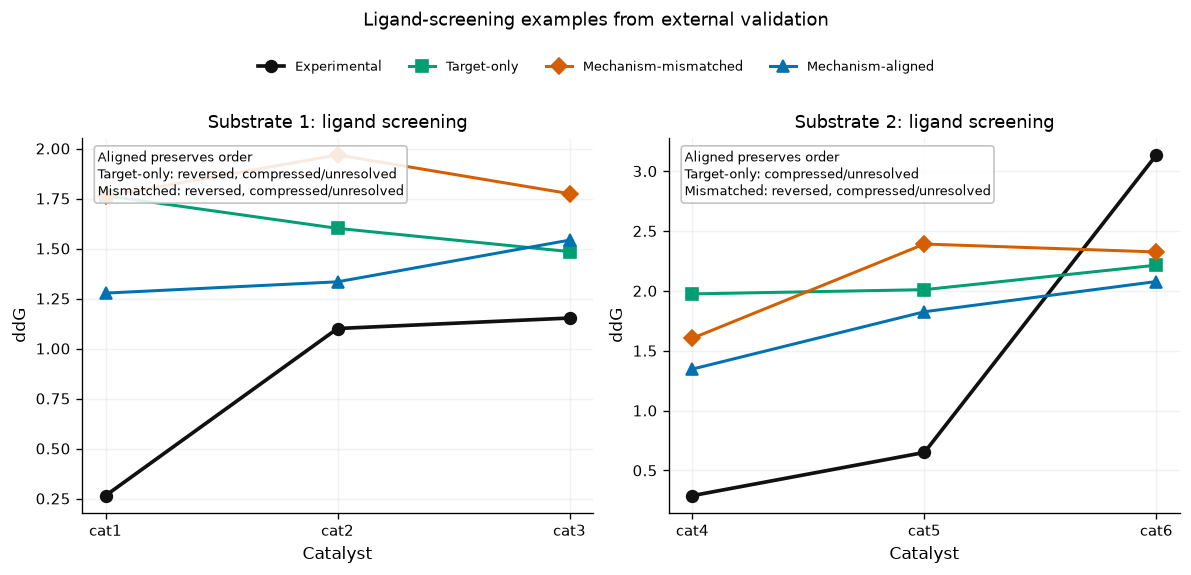

Saved: results/3_2_reaction_series_case_analysis/figures/main_text_ligand_screening_examples.svg


In [34]:
def save_svg_figure(fig, path: Path) -> None:
    fig.savefig(
        path,
        format="svg",
        bbox_inches="tight",
        facecolor="white",
    )
    ET.parse(path)


n_cases = len(DISPLAY_SELECTION)
fig, axes = plt.subplots(
    1,
    n_cases,
    figsize=(5.0 * n_cases, 4.3),
    squeeze=False,
    sharey=False,
)
axes = axes.ravel()

for ax, (_, case) in zip(
    axes,
    DISPLAY_SELECTION.sort_values(
        "case_number"
    ).iterrows(),
):
    case_number = int(case["case_number"])
    subset = (
        DISPLAY_ITEMS.loc[
            DISPLAY_ITEMS["case_number"].eq(
                case_number
            )
        ]
        .sort_values(
            ["y_true", "item_id"],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    x = np.arange(len(subset))
    plot_series = OrderedDict(
        [
            (
                "experimental",
                subset["y_true"].to_numpy(dtype=float),
            ),
            (
                "target_only",
                subset[
                    "pred_target_only"
                ].to_numpy(dtype=float),
            ),
            (
                "mechanism_mismatched",
                subset[
                    "pred_mechanism_mismatched"
                ].to_numpy(dtype=float),
            ),
            (
                "mechanism_aligned",
                subset[
                    "pred_mechanism_aligned"
                ].to_numpy(dtype=float),
            ),
        ]
    )

    for series_key, values in plot_series.items():
        ax.plot(
            x,
            values,
            marker=SCENARIO_MARKERS[series_key],
            color=SCENARIO_COLORS[series_key],
            linewidth=(
                2.2
                if series_key == "experimental"
                else 1.8
            ),
            markersize=7.0,
            label=(
                "Experimental"
                if series_key == "experimental"
                else SCENARIO_LABELS[series_key]
            ),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(subset["display_item_label"])
    ax.set_xlabel("Catalyst")
    ax.set_ylabel("ddG")
    ax.grid(alpha=0.16)
    ax.set_title(
        f"Substrate {case_number}: ligand screening"
    )

    reason_text = (
        "Aligned preserves order\n"
        f"Target-only: "
        f"{subset_failure_label({key.split('__', 1)[1]: case[key] for key in case.index if key.startswith('target_only__')})}\n"
        f"Mismatched: "
        f"{subset_failure_label({key.split('__', 1)[1]: case[key] for key in case.index if key.startswith('mechanism_mismatched__')})}"
    )
    ax.text(
        0.03,
        0.97,
        reason_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "#BBBBBB",
            "alpha": 0.88,
        },
    )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
)
fig.suptitle(
    "Ligand-screening examples from external validation",
    y=1.10,
)
fig.tight_layout()

MAIN_FIGURE_PATH = (
    FIGURE_DIR / "main_text_ligand_screening_examples.svg"
)
save_svg_figure(fig, MAIN_FIGURE_PATH)
plt.show()

print(
    "Saved:",
    MAIN_FIGURE_PATH.relative_to(PROJECT_ROOT),
)


## 7. Generate structure sheets for the two displayed ligand screens


Case 1: results/3_2_reaction_series_case_analysis/structures/substrate_01_ligand_screening_structures.svg


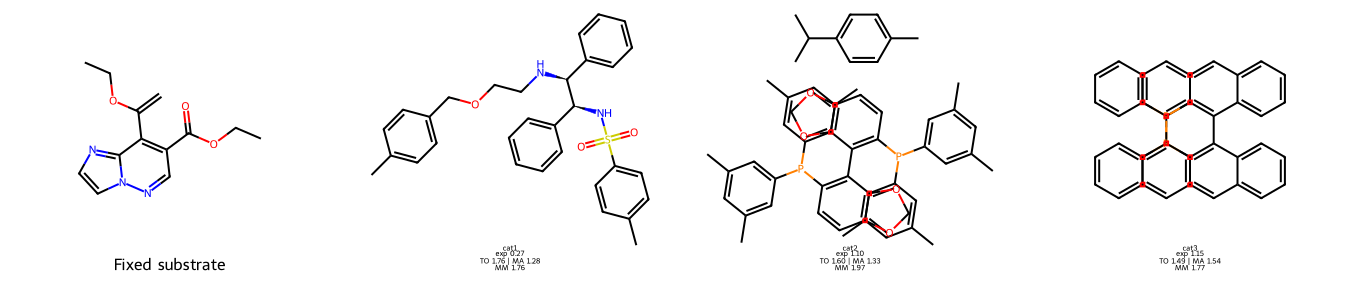

,case_number,display_label,series_type_label,series_id,fixed_structure_label,fixed_structure_smiles,item_id,display_item_label,varying_smiles,experimental_ddG,pred_target_only,pred_mechanism_aligned,pred_mechanism_mismatched,selection_reason
0,1,Substrate 1 ligand screen,Ligand variation,ligand_variation_d414a8d644cd,Fixed substrate,C=C(OCC)c1c(C(=O)OCC)cnn2ccnc12,L1,cat1,Cc1ccc(COCCN[C@@H](c2ccccc2)[C@@H](NS(=O)(=O)c...,0.2650,1.7646,1.2776,1.7621,aligned preserves experimental order; target-o...
1,1,Substrate 1 ligand screen,Ligand variation,ligand_variation_d414a8d644cd,Fixed substrate,C=C(OCC)c1c(C(=O)OCC)cnn2ccnc12,L3,cat2,Cc1cc(C)cc(P(c2cc(C)cc(C)c2)c2ccc3c(c2-c2c(P(c...,1.1005,1.6014,1.3341,1.9683,aligned preserves experimental order; target-o...
2,1,Substrate 1 ligand screen,Ligand variation,ligand_variation_d414a8d644cd,Fixed substrate,C=C(OCC)c1c(C(=O)OCC)cnn2ccnc12,L4,cat3,c1ccc(P(c2ccccc2)c2ccc3ccccc3c2-c2c(P(c3ccccc3...,1.1529,1.4852,1.5425,1.7748,aligned preserves experimental order; target-o...


Case 2: results/3_2_reaction_series_case_analysis/structures/substrate_02_ligand_screening_structures.svg


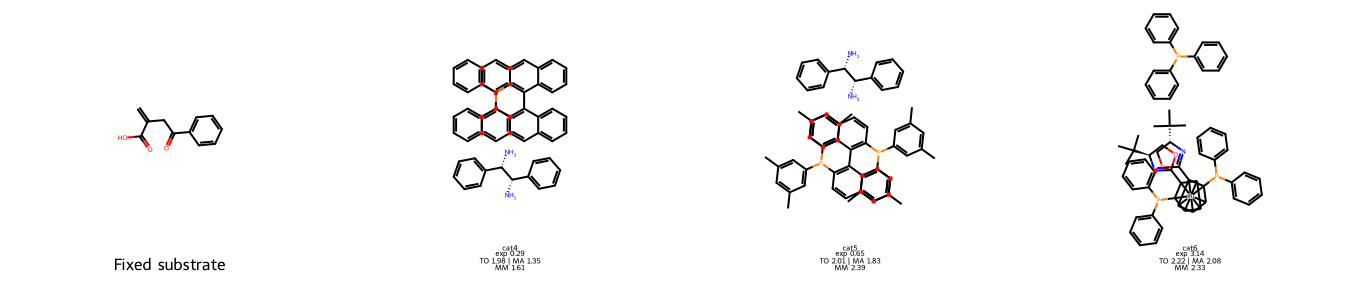

,case_number,display_label,series_type_label,series_id,fixed_structure_label,fixed_structure_smiles,item_id,display_item_label,varying_smiles,experimental_ddG,pred_target_only,pred_mechanism_aligned,pred_mechanism_mismatched,selection_reason
0,2,Substrate 2 ligand screen,Ligand variation,ligand_variation_27f9097b08f8,Fixed substrate,C=C(CC(=O)c1ccccc1)C(=O)O,L1,cat4,N[C@@H](c1ccccc1)[C@@H](N)c1ccccc1.c1ccc(P(c2c...,0.2900,1.9755,1.3474,1.6050,aligned preserves experimental order; target-o...
1,2,Substrate 2 ligand screen,Ligand variation,ligand_variation_27f9097b08f8,Fixed substrate,C=C(CC(=O)c1ccccc1)C(=O)O,L4,cat5,Cc1cc(C)cc(P(c2cc(C)cc(C)c2)c2ccc3ccccc3c2-c2c...,0.6509,2.0109,1.8264,2.3921,aligned preserves experimental order; target-o...
2,2,Substrate 2 ligand screen,Ligand variation,ligand_variation_27f9097b08f8,Fixed substrate,C=C(CC(=O)c1ccccc1)C(=O)O,L6,cat6,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,3.1362,2.2154,2.0787,2.3258,aligned preserves experimental order; target-o...


In [35]:
def normalize_text(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.casefold() in {
        "",
        "nan",
        "none",
        "null",
        "<na>",
    }:
        return ""
    return text


def mol_or_placeholder(smiles: str):
    molecule = Chem.MolFromSmiles(
        normalize_text(smiles)
    )
    if molecule is not None:
        return molecule
    return Chem.MolFromSmiles("[*]")


def format_prediction_legend(item: pd.Series) -> str:
    return (
        f"{item['display_item_label']}\n"
        f"exp {item['y_true']:.2f}\n"
        f"TO {item['pred_target_only']:.2f} | "
        f"MA {item['pred_mechanism_aligned']:.2f}\n"
        f"MM {item['pred_mechanism_mismatched']:.2f}"
    )


if SERIES_IDENTITIES["series_id"].duplicated().any():
    duplicated_ids = SERIES_IDENTITIES.loc[
        SERIES_IDENTITIES["series_id"].duplicated(keep=False),
        "series_id",
    ].tolist()
    raise ValueError(
        f"SERIES_IDENTITIES contains duplicated series_id values: "
        f"{duplicated_ids[:10]}"
    )

identity_lookup = SERIES_IDENTITIES.set_index(
    "series_id",
    drop=False,
)
structure_manifest_rows = []

for _, case in DISPLAY_SELECTION.sort_values(
    "case_number"
).iterrows():
    case_number = int(case["case_number"])
    identity = identity_lookup.loc[
        case["series_id"]
    ]
    subset = (
        DISPLAY_ITEMS.loc[
            DISPLAY_ITEMS["case_number"].eq(
                case_number
            )
        ]
        .sort_values(
            ["y_true", "item_id"],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    molecules = [
        mol_or_placeholder(
            identity["fixed_structure_smiles"]
        )
    ]
    legends = [
        identity["fixed_structure_label"]
    ]

    for _, item in subset.iterrows():
        molecules.append(
            mol_or_placeholder(
                item["varying_smiles"]
            )
        )
        legends.append(
            format_prediction_legend(item)
        )
        structure_manifest_rows.append(
            {
                "case_number": case_number,
                "series_id": case["series_id"],
                "series_type": case["series_type"],
                "item_id": item["item_id"],
                "display_item_label": item["display_item_label"],
                "fixed_structure_label": identity[
                    "fixed_structure_label"
                ],
                "fixed_structure_smiles": identity[
                    "fixed_structure_smiles"
                ],
                "varying_smiles": item[
                    "varying_smiles"
                ],
                "canonical_item": item[
                    "canonical_item"
                ],
                "experimental_ddG": item["y_true"],
                "pred_target_only": item[
                    "pred_target_only"
                ],
                "pred_mechanism_aligned": item[
                    "pred_mechanism_aligned"
                ],
                "pred_mechanism_mismatched": item[
                    "pred_mechanism_mismatched"
                ],
            }
        )

    svg = Draw.MolsToGridImage(
        molecules,
        legends=legends,
        molsPerRow=min(4, len(molecules)),
        subImgSize=(340, 285),
        useSVG=True,
    )
    svg_text = (
        svg.data
        if hasattr(svg, "data")
        else str(svg)
    )
    opening_end = svg_text.find(">")
    svg_text = (
        svg_text[: opening_end + 1]
        + '<rect x="0" y="0" width="100%" '
        'height="100%" fill="#ffffff"/>'
        + svg_text[opening_end + 1 :]
    )

    structure_path = (
        STRUCTURE_DIR
        / f"substrate_{case_number:02d}_"
        "ligand_screening_structures.svg"
    )
    structure_path.write_text(
        svg_text,
        encoding="utf-8",
    )
    ET.parse(structure_path)

    print(
        f"Case {case_number}:",
        structure_path.relative_to(PROJECT_ROOT),
    )
    display(SVG(filename=str(structure_path)))

    case_display_df = subset[
        [
            "case_number",
            "display_label",
            "series_type_label",
            "series_id",
            "item_id",
            "display_item_label",
            "varying_smiles",
            "y_true",
            "pred_target_only",
            "pred_mechanism_aligned",
            "pred_mechanism_mismatched",
            "selection_reason",
        ]
    ].copy()
    case_display_df.insert(
        4,
        "fixed_structure_label",
        identity["fixed_structure_label"],
    )
    case_display_df.insert(
        5,
        "fixed_structure_smiles",
        identity["fixed_structure_smiles"],
    )
    case_display_df = case_display_df.rename(
        columns={
            "y_true": "experimental_ddG",
        }
    )
    numeric_cols = [
        "experimental_ddG",
        "pred_target_only",
        "pred_mechanism_aligned",
        "pred_mechanism_mismatched",
    ]
    case_display_df[numeric_cols] = case_display_df[numeric_cols].round(4)
    display(case_display_df)

STRUCTURE_MANIFEST = pd.DataFrame(
    structure_manifest_rows
)
STRUCTURE_MANIFEST.to_csv(
    TABLE_DIR
    / "display_subset_structure_manifest.csv",
    index=False,
)



## 8. Validate the selected ligand-screening examples


In [36]:
display(
    DISPLAY_ITEMS[
        [
            "case_number",
            "display_label",
            "series_type_label",
            "series_id",
            "item_id",
            "display_item_label",
            "varying_smiles",
            "y_true",
            "pred_target_only",
            "pred_mechanism_aligned",
            "pred_mechanism_mismatched",
            "selection_reason",
        ]
    ].round(4)
)

score_lookup = pd.concat(
    [PAIR_SCORES, TRIPLET_SCORES],
    ignore_index=True,
)
score_keys = set(
    zip(
        score_lookup["series_id"],
        score_lookup["subset_size"],
        score_lookup["selected_item_ids"],
    )
)
selected_keys = set(
    zip(
        DISPLAY_SELECTION["series_id"],
        DISPLAY_SELECTION["subset_size"],
        DISPLAY_SELECTION["selected_item_ids"],
    )
)

expected_structure_paths = [
    STRUCTURE_DIR
    / (
        f"substrate_{int(case['case_number']):02d}_"
        "ligand_screening_structures.svg"
    )
    for _, case in DISPLAY_SELECTION.iterrows()
]

for path in [
    MAIN_FIGURE_PATH,
    *expected_structure_paths,
]:
    if not path.exists():
        raise FileNotFoundError(path)
    ET.parse(path)

selection_qc = pd.DataFrame(
    [
        {
            "check": (
                "all displayed subsets occur in complete "
                "candidate tables"
            ),
            "passed": selected_keys.issubset(
                score_keys
            ),
        },
        {
            "check": (
                "all displayed cases use allowed evidence tiers"
            ),
            "passed": DISPLAY_SELECTION[
                "display_tier"
            ].isin(ALLOWED_DISPLAY_TIERS).all(),
        },
        {
            "check": (
                "mechanism-aligned ordering is perfect "
                "within every displayed subset"
            ),
            "passed": np.allclose(
                DISPLAY_SELECTION[
                    "aligned_order_accuracy"
                ],
                1.0,
            ),
        },
        {
            "check": (
                "at least one competitor failure occurs "
                "in every displayed subset"
            ),
            "passed": (
                DISPLAY_SELECTION[
                    "competitor_failure_count"
                ]
                >= 1
            ).all(),
        },
        {
            "check": (
                "main-text and structure SVG files parse"
            ),
            "passed": True,
        },
    ]
)
selection_qc.to_csv(
    TABLE_DIR / "display_subset_selection_qc.csv",
    index=False,
)
display(selection_qc)

if not selection_qc["passed"].all():
    raise AssertionError(
        "One or more illustrative-subset QC checks failed."
    )

print(
    "All 3.2 ligand-screening checks passed."
)
print(
    "Interpretation boundary: the selected ligand-screening cases are "
    "transparent post hoc illustrations. Aggregate external "
    "validation remains notebook 3.1."
)


,case_number,display_label,series_type_label,series_id,item_id,display_item_label,varying_smiles,y_true,pred_target_only,pred_mechanism_aligned,pred_mechanism_mismatched,selection_reason
0,1,Substrate 1 ligand screen,Ligand variation,ligand_variation_d414a8d644cd,L1,cat1,Cc1ccc(COCCN[C@@H](c2ccccc2)[C@@H](NS(=O)(=O)c...,0.2650,1.7646,1.2776,1.7621,aligned preserves experimental order; target-o...
1,1,Substrate 1 ligand screen,Ligand variation,ligand_variation_d414a8d644cd,L3,cat2,Cc1cc(C)cc(P(c2cc(C)cc(C)c2)c2ccc3c(c2-c2c(P(c...,1.1005,1.6014,1.3341,1.9683,aligned preserves experimental order; target-o...
2,1,Substrate 1 ligand screen,Ligand variation,ligand_variation_d414a8d644cd,L4,cat3,c1ccc(P(c2ccccc2)c2ccc3ccccc3c2-c2c(P(c3ccccc3...,1.1529,1.4852,1.5425,1.7748,aligned preserves experimental order; target-o...
3,2,Substrate 2 ligand screen,Ligand variation,ligand_variation_27f9097b08f8,L1,cat4,N[C@@H](c1ccccc1)[C@@H](N)c1ccccc1.c1ccc(P(c2c...,0.2900,1.9755,1.3474,1.6050,aligned preserves experimental order; target-o...
4,2,Substrate 2 ligand screen,Ligand variation,ligand_variation_27f9097b08f8,L4,cat5,Cc1cc(C)cc(P(c2cc(C)cc(C)c2)c2ccc3ccccc3c2-c2c...,0.6509,2.0109,1.8264,2.3921,aligned preserves experimental order; target-o...
5,2,Substrate 2 ligand screen,Ligand variation,ligand_variation_27f9097b08f8,L6,cat6,CC(C)(C)[C@H]1COC([C]23[CH]4[CH]5[CH]6[C]2(P(c...,3.1362,2.2154,2.0787,2.3258,aligned preserves experimental order; target-o...


,check,passed
0,all displayed subsets occur in complete candid...,True
1,all displayed cases use allowed evidence tiers,True
2,mechanism-aligned ordering is perfect within e...,True
3,at least one competitor failure occurs in ever...,True
4,main-text and structure SVG files parse,True


All 3.2 ligand-screening checks passed.
Interpretation boundary: the selected ligand-screening cases are transparent post hoc illustrations. Aggregate external validation remains notebook 3.1.
